# 01 — Data Collection & Preprocessing

Download AG News, inspect the corpus, combine title and description, and create cleaned tokens for LDA.

In [5]:
import pandas as pd
import matplotlib.pyplot as plt
from datasets import load_dataset

dataset=load_dataset("fancyzhx/ag_news")
train=pd.DataFrame(dataset["train"])
test=pd.DataFrame(dataset["test"])
print(train.shape, test.shape)
train.head()

(120000, 2) (7600, 2)


,text,label
0,Wall St. Bears Claw Back Into the Black (Reute...,2
1,Carlyle Looks Toward Commercial Aerospace (Reu...,2
2,Oil and Economy Cloud Stocks' Outlook (Reuters...,2
3,Iraq Halts Oil Exports from Main Southern Pipe...,2
4,"Oil prices soar to all-time record, posing new...",2


In [6]:
label_names=["World","Sports","Business","Sci/Tech"]
train["category"]=train["label"].map(dict(enumerate(label_names)))
train["text"] = train["text"].fillna("").astype(str)
print(train["category"].value_counts())

category
Business    30000
Sci/Tech    30000
Sports      30000
World       30000
Name: count, dtype: int64


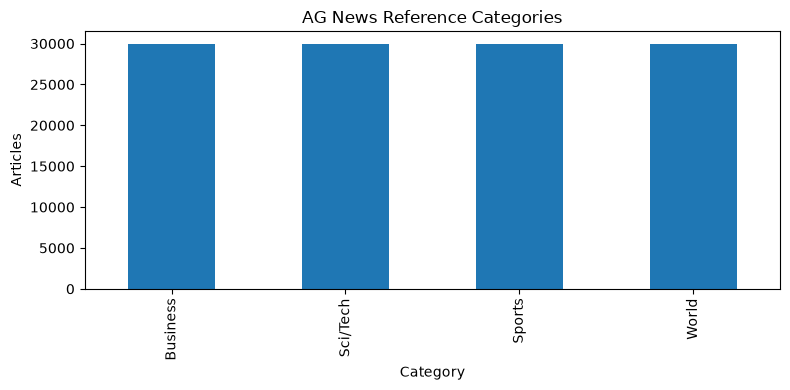

In [7]:
plt.figure(figsize=(8,4))
train["category"].value_counts().plot(kind="bar")
plt.title("AG News Reference Categories")
plt.xlabel("Category"); plt.ylabel("Articles"); plt.tight_layout(); plt.show()

## Text preprocessing

LDA needs tokens. We remove URLs, punctuation, common English stopwords, and very short words.

In [8]:
stop_words = set("a about above after again against all am an and any are as at be because been before being below between both but by can could did do does doing down during each few for from further had has have having he her here hers herself him himself his how i if in into is it its itself just me more most my myself no nor not of off on once only or other our ours ourselves out over own same she should so some such than that the their theirs them themselves then there these they this those through to too under until up very was we were what when where which while who whom why will with would you your yours yourself yourselves".split())

def clean_text(text):
    import re, string
    text=text.lower(); text=re.sub(r"http\S+|www\S+"," ",text)
    text=text.translate(str.maketrans("","",string.punctuation))
    return [t for t in re.findall(r"[a-z]{3,}",text) if t not in stop_words]

In [9]:
train["tokens"]=train["text"].map(clean_text)
train["token_count"]=train["tokens"].str.len()
train[["text","tokens","token_count"]].head()

,text,tokens,token_count
0,Wall St. Bears Claw Back Into the Black (Reute...,"[wall, bears, claw, back, black, reuters, reut...",14
1,Carlyle Looks Toward Commercial Aerospace (Reu...,"[carlyle, looks, toward, commercial, aerospace...",25
2,Oil and Economy Cloud Stocks' Outlook (Reuters...,"[oil, economy, cloud, stocks, outlook, reuters...",24
3,Iraq Halts Oil Exports from Main Southern Pipe...,"[iraq, halts, oil, exports, main, southern, pi...",26
4,"Oil prices soar to all-time record, posing new...","[oil, prices, soar, alltime, record, posing, n...",28


In [10]:
train[["label","category","text","tokens"]].to_pickle("../data/ag_news_preprocessed.pkl")
print("Saved preprocessed data.")

Saved preprocessed data.
